In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, stats
print('loaded!')

loaded!


In [2]:
df = pd.read_csv('product_sales.csv')
print(df['sales_method'].unique())
print(f"Unique Customers: {df['customer_id'].nunique()}, total customers: {len(df)}")
#print(df.sort_values('revenue', ascending = False)[['customer_id', 'revenue']].head())


['Email' 'Email + Call' 'Call' 'em + call' 'email']
Unique Customers: 15000, total customers: 15000


# Validation

In [3]:
print(f'Length of Unique states:', len(df['state'].unique()))
print(df[['nb_sold', 'years_as_customer', 'nb_site_visits']].describe())
print(df[['customer_id', 'state']].info())

Length of Unique states: 50
            nb_sold  years_as_customer  nb_site_visits
count  15000.000000       15000.000000    15000.000000
mean      10.084667           4.965933       24.990867
std        1.812213           5.044952        3.500914
min        7.000000           0.000000       12.000000
25%        9.000000           1.000000       23.000000
50%       10.000000           3.000000       25.000000
75%       11.000000           7.000000       27.000000
max       16.000000          63.000000       41.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  15000 non-null  object
 1   state        15000 non-null  object
dtypes: object(2)
memory usage: 234.5+ KB
None


Looking at the info above we should do 3 things: 
1. Investigate years_as_customer: there's a max of 63 which is longer than Pens and Printers has been in business
2. convert customer_id to string
3. convert state to string

In [4]:
# print customers that have been customers longer than Pens and Printers has been in business
print(df[df['years_as_customer'] >= (2026-1984)]) 

# since there's just 2 of them I'm going to drop them considering I don't have more info. 
# If I did have more info we could re-calculate the years they've been customers but since it's only 0.01% I'm not worried about them
df = df[df['years_as_customer'] <= (2026-1984)]
print(df.shape)

       week sales_method                           customer_id  nb_sold  \
13741     2        Email  18919515-a618-430c-9a05-2c7d8fea96af       10   
13800     4         Call  2ea97d34-571d-4e1b-95be-fea1c404649f       10   

       revenue  years_as_customer  nb_site_visits       state  
13741    97.22                 63              24  California  
13800    50.47                 47              27  California  
(14998, 8)


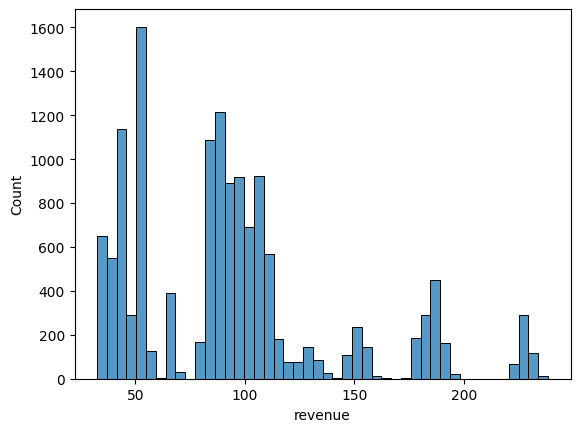

In [5]:
sns.histplot(x = 'revenue', data = df)
plt.show()

The histogram above shows us that there are a handful of data points that appear to be outliers. 
However given the scale [0,238.32] they aren't outliers that I would be concerned about being false and should be included in all calculations, projections, and recommendations. 

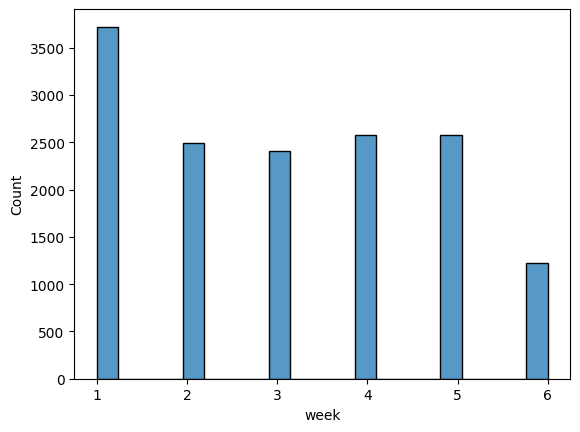

In [6]:
sns.histplot(x = 'week', data = df)
plt.show()

It appears the number of sales we make go down after week 1 and dips again at week 6. This may be due to a plethora of reasons (early excitement, patient buyers, larger sales waiting for later weeks, etc.)

Let's address the missing data points. 
Since we are above a 5% threshold on missing data we can't just ignore it. So instead we'll need to impute it by either using the median, mode, or mean values. Because of the contact methods being Email, Call, and Email + Call we'll look at the distribution of these 3 and then decide. 

In [7]:
# need to replace em+call and email
df['sales_method'] = df['sales_method'].replace({
    'em + call': 'Email + Call', 
    'email': 'Email'
})

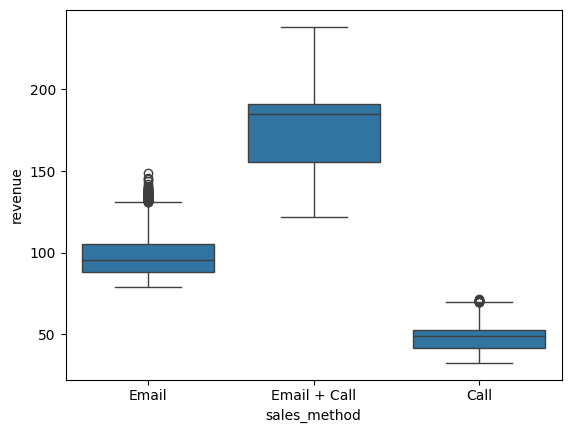

In [8]:
sns.boxplot(x = 'sales_method', y = 'revenue', data = df)
plt.show()

Since our we have a couple of outliers in the Email and Call methods and from before we see Revenue is a bit right-skewed we'll opt to import the median value based on the sales methods. 

In [9]:
# calculate the median revenue and convert to dict
sales_method_median = df.groupby('sales_method')['revenue'].median()
revenue_dict = dict(sales_method_median)

# map to missing values of revenue by sales_method
df['revenue'] = df['revenue'].fillna(df['sales_method'].map(revenue_dict))

Something of concern that the company should look into is that our of 14,998 data points we have no repeat customer_ids. 
This seems highly unlikely and leads me to believe that they are being recorded under different customer_ids. This would be an important detail to look into as finding customers that return to buy more would be a good source of profit generation.

Another step needed in data validation, sales methods were joined together for things such as "email" vs "Email"

Finally, to find the correlation between our predictors and revenue we need to create dummy columns for our non numeric predictors such as the sales methods and states. We'll do that next. 

---

# Analysis

In [10]:
# check return customers
per_customer_revenue = (df.groupby('customer_id')['revenue'].sum().reset_index()
    .sort_values('revenue', ascending = False))
print(f"Unique Customers: {df['customer_id'].nunique()}, total customers: {len(df)}")

# found none!

Unique Customers: 14998, total customers: 14998


In [11]:
print(df['sales_method'].unique())

['Email' 'Email + Call' 'Call']


In [12]:
# create dummy columns for columns 
df_encoded = pd.get_dummies(df, columns=['sales_method', 'state'], drop_first=True)

y = df_encoded['revenue']
df_encoded = df_encoded.drop('revenue', axis = 1)
X = df_encoded

In [13]:
# to compare correlation factors
results = []
for col in X.columns:
    if not np.issubdtype(X[col].dtype, np.number):
        print(f'Skipping: {col}')
        continue
    r, p = pearsonr(X[col], y)
    results.append([col, r, p])

# create DataFrame for ease of viewing
corr_df = pd.DataFrame(results, columns = ['predictor', 'r', 'p'])
corr_df = corr_df.sort_values('r', key = abs, ascending = False)
important_corr = corr_df[corr_df['p'] < 0.05]
important_corr = important_corr[important_corr['r'] > .1]
print(important_corr)
print(corr_df[corr_df['predictor'] == 'sales_method_Email'])

Skipping: customer_id
Skipping: sales_method_Email
Skipping: sales_method_Email + Call
Skipping: state_Alaska
Skipping: state_Arizona
Skipping: state_Arkansas
Skipping: state_California
Skipping: state_Colorado
Skipping: state_Connecticut
Skipping: state_Delaware
Skipping: state_Florida
Skipping: state_Georgia
Skipping: state_Hawaii
Skipping: state_Idaho
Skipping: state_Illinois
Skipping: state_Indiana
Skipping: state_Iowa
Skipping: state_Kansas
Skipping: state_Kentucky
Skipping: state_Louisiana
Skipping: state_Maine
Skipping: state_Maryland
Skipping: state_Massachusetts
Skipping: state_Michigan
Skipping: state_Minnesota
Skipping: state_Mississippi
Skipping: state_Missouri
Skipping: state_Montana
Skipping: state_Nebraska
Skipping: state_Nevada
Skipping: state_New Hampshire
Skipping: state_New Jersey
Skipping: state_New Mexico
Skipping: state_New York
Skipping: state_North Carolina
Skipping: state_North Dakota
Skipping: state_Ohio
Skipping: state_Oklahoma
Skipping: state_Oregon
Skipping

C:\Users\crees\AppData\Local\Temp\ipykernel_9164\731827200.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(xlabel = 'Emailed and Called Client', xticklabels = ['No', 'Yes'])


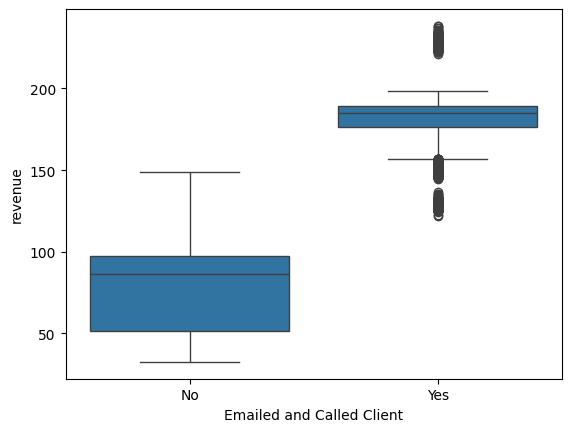

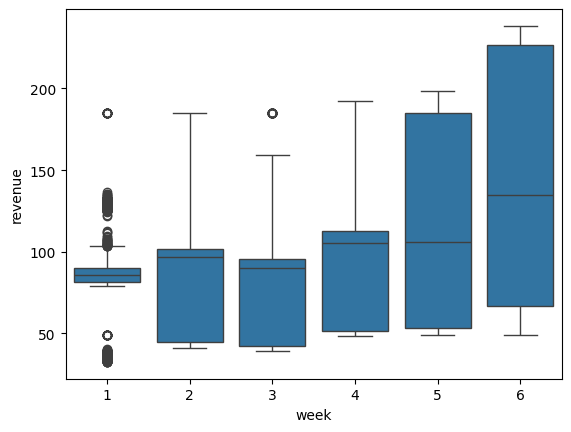

F-stat: 34951.95, P value: 0.0


C:\Users\crees\AppData\Local\Temp\ipykernel_9164\731827200.py:11: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  f_stat, p_val = stats.f_oneway(rev_no, rev_yes)


In [14]:
best_predictors = ['sales_method_Email + Call', 'nb_sold', 'week', 'nb_site_visits']
ax = sns.boxplot(x=df_encoded['sales_method_Email + Call'], y = y)
ax.set(xlabel = 'Emailed and Called Client', xticklabels = ['No', 'Yes'])
plt.show()
ax2 = sns.boxplot(x = df_encoded['week'], y = y)
ax2.set(xlabel = 'week')
plt.show()

rev_no = y[df_encoded['sales_method_Email + Call'] == 0]
rev_yes = y[df_encoded['sales_method_Email + Call'] == 1]
f_stat, p_val = stats.f_oneway(rev_no, rev_yes)
print(f'F-stat: {f_stat:.2f}, P value: {p_val}')

From our box plots we can see it appears that the mean revenue between our two groups (Yes: email and phone call versus No: not both) is significantly different. We also see that as the weeks go by past week 3 we see our lower quartile increase slightly and the IQR expands massively. 

After conducting a one-way ANOVA test on Phone & Email we can conclude there is a significant difference between the two. A p-value of under 0.05 means it is significant and an F-stat well above 1 (34,952!!) means we have very strong evidence that the average revenue for making a phone call and sending an email is higher than just one or neither. 

Customer by sales method: 
sales_method
Email           7465
Call            4961
Email + Call    2572
Name: count, dtype: int64
               count        mean        std     min       25%     50%  \
sales_method                                                            
Call          4961.0   47.649883   8.456520   32.54   41.6300   49.05   
Email         7465.0   97.014887  10.802488   78.83   88.3900   95.58   
Email + Call  2572.0  183.798970  27.040536  122.11  176.4375  184.74   

                  75%     max  
sales_method                   
Call           52.590   71.36  
Email         104.460  148.97  
Email + Call  189.535  238.32  


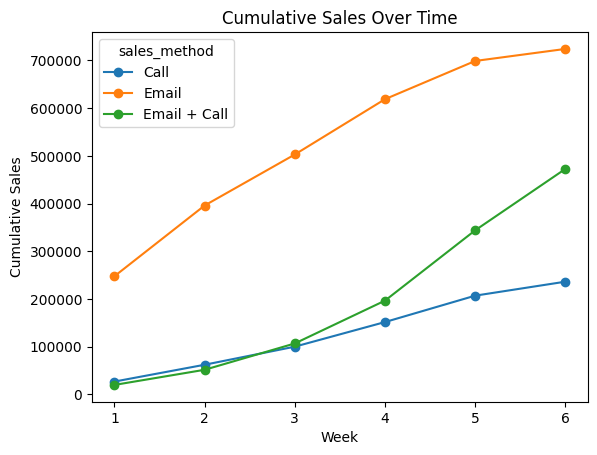

In [15]:
customers_per_approach = df['sales_method'].value_counts()

print(f'Customer by sales method: \n{customers_per_approach}')
print(df.groupby('sales_method')['revenue'].describe())

revenueby_week = df.pivot_table(
    values = 'revenue',
    index = 'week',
    columns = 'sales_method',
    aggfunc = 'sum'
)
#revenueby_week.plot(kind ='line')

cumulative = revenueby_week.cumsum()
#print(cumulative)
cumulative_ax = cumulative.plot(marker = 'o')
cumulative_ax.set(xlabel = 'Week', ylabel = 'Cumulative Sales', title = 'Cumulative Sales Over Time')
plt.show()

Customer by sales method: 
sales_method
Email           7465
Call            4961
Email + Call    2572
Name: count, dtype: int64
               count        mean        std     min       25%     50%  \
sales_method                                                            
Call          4961.0   47.649883   8.456520   32.54   41.6300   49.05   
Email         7465.0   97.014887  10.802488   78.83   88.3900   95.58   
Email + Call  2572.0  183.798970  27.040536  122.11  176.4375  184.74   

                  75%     max  
sales_method                   
Call           52.590   71.36  
Email         104.460  148.97  
Email + Call  189.535  238.32  


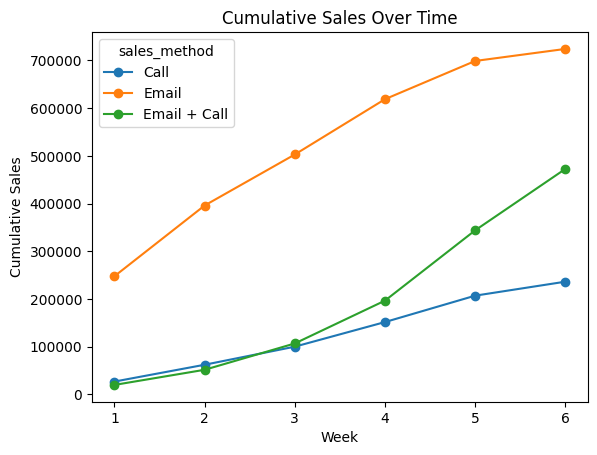

In [16]:
customers_per_approach = df['sales_method'].value_counts()

print(f'Customer by sales method: \n{customers_per_approach}')
print(df.groupby('sales_method')['revenue'].describe())

revenueby_week = df.pivot_table(
    values = 'revenue',
    index = 'week',
    columns = 'sales_method',
    aggfunc = 'sum'
)
#revenueby_week.plot(kind ='line')

cumulative = revenueby_week.cumsum()
#print(cumulative)
cumulative_ax = cumulative.plot(marker = 'o')
cumulative_ax.set(xlabel = 'Week', ylabel = 'Cumulative Sales', title = 'Cumulative Sales Over Time')
plt.show()

**Customers for each approach**

**Email: 7465**

**Call: 4961**

**Email & Call: 2572**

---
# Metric
A good metric to use, given the above, would be total Revenue per Customer by Sales Method. 

The total revenue from the Email method is \$724216.13 but per customer is only around \$97

For the Email + call method we have a total revenue of \$472,730.95 but per customer is much higher at roughly \$184



In [17]:
rev_per_customer = df.groupby('sales_method').agg(
    total_rev = ('revenue', 'sum'),
    num_customers = ('customer_id', 'count')
)

rev_per_customer['rev_per_customer'] = (
    rev_per_customer['total_rev'] / rev_per_customer['num_customers']
)

print(rev_per_customer)

              total_rev  num_customers  rev_per_customer
sales_method                                            
Call          236391.07           4961         47.649883
Email         724216.13           7465         97.014887
Email + Call  472730.95           2572        183.798970


---
# Recommendations

The most telling information is from the line chart where we see Revenue from just an email is leveling off while the Email + Phone Call method is beginning to accelerate. Given the longevity of office stationery we would assume this trend would continue. 

## **Methods to puruse**
1. Email: Continue sending an initial email to customers. It takes very little work and incentivizes customers to make a purchase.
2. Call: Stop making phone calls without an email beforehand. An average of thirty minutes per customer is too much time for very little reward.
3. Email & Phone Call: Focus time and effort here. With a strong correlation coefficient of 0.8 between this method and revenue we know that the two are related. A one-way ANOVA test confirmed that customers who receive an email and phone call spend more on average.

## **Other Recommendation**

Investigate the customer_id field. Currently there are no duplicates which doesn't seem likely. If we can track returning customer we can tap into more information to increase revenue and adjust our methods. 